# ML4SCI DeepLense: Common Test I - Multi-Class Classification
**Applicant:** Nimesh Kavindu
**Objective:** Classify simulated strong gravitational lensing images into three physical categories: No Substructure, Subhalo (Sphere), and Vortex.
**Methodology:** This notebook bypasses standard "black-box" image loading to directly ingest raw `.npy` astrophysical matrices using a custom PyTorch `DataLoader`. It utilizes a mathematically adapted ResNet-18 backbone, utilizing weight-summing to natively process 1-channel data without wasteful channel duplication.

In [1]:
# Install gdown if not already present
!pip install -q gdown

# Download the dataset using the file ID from your link
!gdown --id 1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ

# Unzip the dataset silently to keep the output clean
!unzip -q dataset.zip -d /content/

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=855d6660-3f12-451f-a8c1-8c919b5e27cf
To: /content/dataset.zip
100% 1.13G/1.13G [00:23<00:00, 48.7MB/s]


## 1. Custom Scientific Data Pipeline & Augmentation
Astrophysical data consists of 1-channel `.npy` matrices representing photon surface brightness, which standard image loaders cannot process natively. 
* **The 90:10 Split:** The provided dataset directory inherently separates the data into `train` and `val` folders, satisfying the required 90:10 train-test split without data leakage.
* **Physics-Safe Augmentation:** To prevent overfitting on the faint, complex topological features of vortex substructures, physical symmetries (random horizontal/vertical flips and 90-degree rotations) are dynamically applied to the training set.

In [2]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T

class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.classes = ['no', 'sphere', 'vort']
        self.filepaths = []
        self.labels = []
        self.transform = transform # New: Add transform capability

        for idx, cls in enumerate(self.classes):
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for file in os.listdir(cls_dir):
                    if file.endswith('.npy'):
                        self.filepaths.append(os.path.join(cls_dir, file))
                        self.labels.append(idx)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_array = np.load(self.filepaths[idx])
        if len(img_array.shape) == 2:
            img_array = np.expand_dims(img_array, axis=0)

        img_tensor = torch.from_numpy(img_array).float()

        # New: Apply the augmentations if they exist
        if self.transform:
            img_tensor = self.transform(img_tensor)

        label = self.labels[idx]
        return img_tensor, label

# 1. Define the augmentations (flips and 90-degree rotations)
train_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=90),
])

# 2. Apply transforms ONLY to the training data. Validation data must remain untouched.
train_dataset = LensingDataset(root_dir='/content/dataset/train', transform=train_transforms)
val_dataset = LensingDataset(root_dir='/content/dataset/val', transform=None)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## 2. Domain-Adapted ResNet-18 Backbone
Standard transfer learning models expect 3-channel (RGB) images. A naive approach is to duplicate the 1-channel astrophysics data three times, but this artificially bloats the tensor size and dilutes the physical gradients.
* **The `Conv1` Adaptation:** Instead of duplicating the data, we mathematically adapt the pre-trained architecture. We replace the first convolutional layer (`conv1`) with a 1-channel equivalent. To preserve the pre-trained feature extraction weights, we sum the original 3-channel weights across the channel dimension. This allows the network to ingest raw physical matrices natively while retaining its deep feature knowledge.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load the model WITH pre-trained weights
model = models.resnet18(weights='DEFAULT')

# 2. Modify the first convolutional layer for 1-channel (grayscale)
original_conv1 = model.conv1
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
with torch.no_grad():
    model.conv1.weight[:] = torch.sum(original_conv1.weight, dim=1, keepdim=True)

# 3. Modify the final fully connected layer to output 3 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3)

# Move to GPU
model = model.to(device)

## 3. Dynamic Training Engine
Training deep networks from scratch on noisy astrophysical matrices often leads to exploding gradients or "catastrophic forgetting," causing the model to flatline at a uniform 33.33% probability guess.
* **Adaptive Learning:** We utilize the `AdamW` optimizer paired with a `ReduceLROnPlateau` scheduler. By monitoring the validation loss, the scheduler halves the learning rate when the network stalls, allowing for microscopic weight adjustments. 
* **Early Stopping:** The loop tracks the `best_val_acc` and automatically saves the state dictionary of the optimal epoch to prevent overfitting.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

num_epochs = 20
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    lr_msg = f"\n   -> [LR reduced to {new_lr}]" if current_lr != new_lr else ""

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        saved_msg = " -> [Model Saved!]"
    else:
        saved_msg = ""

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_accuracy:.2f}%{saved_msg}{lr_msg}")

print(f"\nTraining complete. Loading the best model (Accuracy: {best_val_acc:.2f}%) for final evaluation...")
model.load_state_dict(torch.load('best_model.pth'))

Epoch [1/20] - Train Loss: 1.0189 - Val Loss: 0.8181 - Val Acc: 58.89% -> [Model Saved!]
Epoch [2/20] - Train Loss: 0.6653 - Val Loss: 0.5437 - Val Acc: 77.16% -> [Model Saved!]
Epoch [3/20] - Train Loss: 0.5340 - Val Loss: 0.5676 - Val Acc: 78.44% -> [Model Saved!]
Epoch [4/20] - Train Loss: 0.4687 - Val Loss: 0.3589 - Val Acc: 86.16% -> [Model Saved!]
Epoch [5/20] - Train Loss: 0.4211 - Val Loss: 0.3589 - Val Acc: 86.11%
Epoch [6/20] - Train Loss: 0.3940 - Val Loss: 0.3374 - Val Acc: 87.37% -> [Model Saved!]
Epoch [7/20] - Train Loss: 0.3667 - Val Loss: 0.2743 - Val Acc: 89.91% -> [Model Saved!]
Epoch [8/20] - Train Loss: 0.3450 - Val Loss: 0.4417 - Val Acc: 81.57%
Epoch [9/20] - Train Loss: 0.3302 - Val Loss: 0.2773 - Val Acc: 89.73%
Epoch [10/20] - Train Loss: 0.3142 - Val Loss: 0.2806 - Val Acc: 89.68%
   -> [LR reduced to 5e-05]
Epoch [11/20] - Train Loss: 0.2678 - Val Loss: 0.2110 - Val Acc: 92.21% -> [Model Saved!]
Epoch [12/20] - Train Loss: 0.2588 - Val Loss: 0.2250 - Val Acc

<All keys matched successfully>

## 4. Evaluation Metrics: ROC, AUC, and Confusion Matrix
The ML4SCI guidelines require evaluating the model's predictive power using the Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC). In the context of dark matter morphology, an AUC approaching 1.0 indicates that the network has successfully learned to isolate the incredibly faint lensing perturbations caused by vortex and spherical subhalos from standard empty lenses.

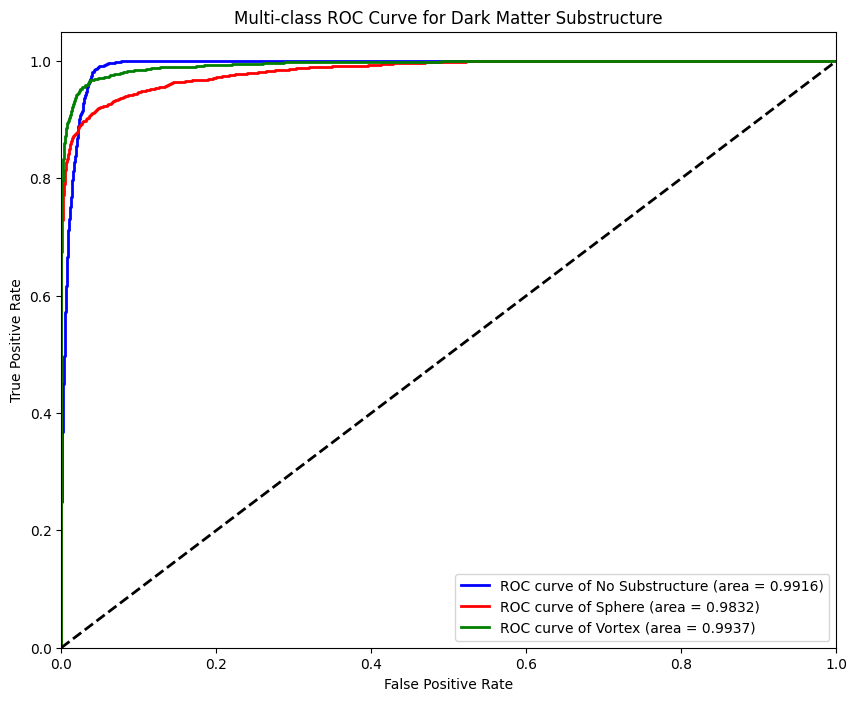

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

# Collect all true labels and prediction probabilities
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        # Apply softmax to get probabilities
        probs = F.softmax(outputs, dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Binarize the true labels for multi-class ROC calculation
# Classes: 0 (No sub), 1 (Sphere), 2 (Vort)
binarized_labels = label_binarize(all_labels, classes=[0, 1, 2])
n_classes = binarized_labels.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
class_names = ['No Substructure', 'Sphere', 'Vortex']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(binarized_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve for Dark Matter Substructure')
plt.legend(loc="lower right")
plt.show()

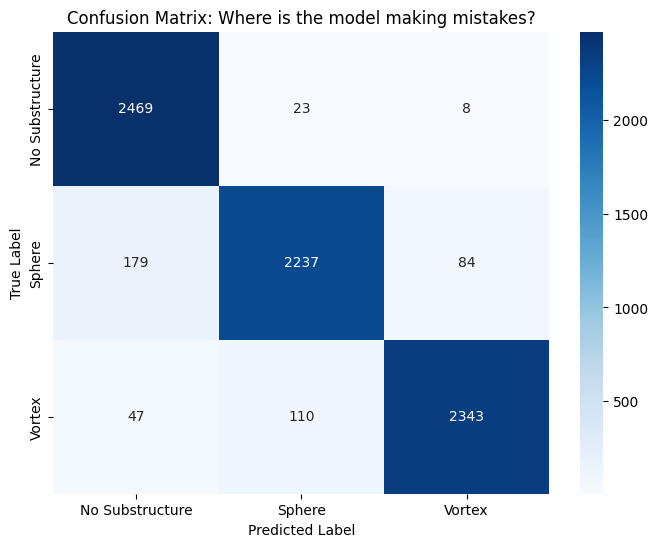


 DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

No Substructure       0.92      0.99      0.95      2500
         Sphere       0.94      0.89      0.92      2500
         Vortex       0.96      0.94      0.95      2500

       accuracy                           0.94      7500
      macro avg       0.94      0.94      0.94      7500
   weighted avg       0.94      0.94      0.94      7500



In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

# 1. Gather all predictions and true labels
all_preds = []
all_true = []

# Ensure the model is in evaluation mode and gradients are disabled
model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Get raw output scores
        outputs = model(inputs)

        # The predicted class is the one with the highest score
        _, preds = torch.max(outputs, 1)

        # Move data back to CPU and convert to numpy for Scikit-Learn
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

# Define the exact class names based on your folder structure
class_names = ['No Substructure', 'Sphere', 'Vortex']

# --- Part 1: The Confusion Matrix ---
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8, 6))
# Create a heatmap using Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Where is the model making mistakes?')
plt.show()

# --- Part 2: The Classification Report ---
print("\n" + "="*50)
print(" DETAILED CLASSIFICATION REPORT")
print("="*50)
# Generate a text report showing Precision, Recall, and F1-Score
print(classification_report(all_true, all_preds, target_names=class_names))